In [53]:
#forces us to reload the libraries each time we do a function call,
#so I can update things in real time
%load_ext autoreload
%autoreload 2
#import path libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from utils import psf
from utils import plotting
from utils import zernike
from optimization import reconstruction
from tqdm import tqdm


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300

In [55]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05             # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
grid_size = 128            # BFP resolution
L_bfp = 15.12              # BFP diameter [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
num_apt = 1.05
L_ffp = 0.0065             # FFP size [mm]
grid_ffp = 64
grid_bfp = 64

In [56]:
np.logspace(0, 2, 5)

array([  1.        ,   3.16227766,  10.        ,  31.6227766 ,
       100.        ])

In [57]:
microscope = psf.Microscope(
    N_order=N_order, lambd=lambd, n=n, num_apt=num_apt, f=f,
    mag=mag, w_0=w_0, L_bfp=L_bfp, grid_bfp=grid_bfp,
)
grid = psf.Centered_Square_Grid(L_ffp=L_ffp, grid_ffp=grid_ffp, z_level=0)

modes = [[0, 4],
    #[2,2], [ -2, 2], [-3, 3], [3, 3]#, [0, 4],
    # [-4, 4], [-2, 4], [2, 4], [4, 4],
   #  [-5, 5], [-3, 5], [-1, 5], [1, 5], [3, 5], [5, 5],
]
ABERRATION_RMS = 0.15
ABERRATION_SEED = 0
NOISE_SEED = 1
RHO = 1e30
OPTICAL_MODE = "vector"
NUM_TRIALS = 1
MAX_ITERATIONS = 20
OPTIMIZATION_METHOD = "gradient"  # "newton" or "gradient"
DIVERSITY_MODE = [2, 2]

diversity_rms_grid = np.array([0.0, 0.025, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3])
snr_grid = np.logspace(0, 2, 5)

# Generate the unknown wavefront once; every grid point uses the same strengths.
aberration = zernike.RMSAberration(
    modes=modes,
    raw_strengths=np.random.default_rng(ABERRATION_SEED).normal(0, 1, len(modes)),
    RMS_desired=ABERRATION_RMS,
    alpha=microscope.alpha,
)

z_sample_levels = np.arange(-0.002, 0.002, 0.0001)
focal_positions = np.arange(-0.002, 0.002, 0.0005)
focal_z_levels = np.tile(focal_positions, 3)
mask_3D = psf.bead_img_3D(
    grid=grid, z_levels=z_sample_levels,
    xs=[0.0], ys=[0.0], zs=[0.0], bead_sizes=[0.001],
)


In [58]:
def poisson_images_at_snr(clean_images, snr, rng):
    clean_images = np.asarray(clean_images, dtype=float)
    peak = clean_images.max()
    if not np.all(np.isfinite(clean_images)) or peak <= 0:
        raise ValueError("Images must be finite with positive signal.")
    if clean_images.min() < -1e-12 * peak:
        raise ValueError("Images must be nonnegative.")
    if not np.isfinite(snr) or snr <= 0:
        raise ValueError("SNR must be finite and positive.")
    unit_images = np.clip(clean_images / peak, 0, None)
    photon_scale = snr**2 * unit_images.sum() / np.sum(unit_images**2)
    return (rng.poisson(photon_scale * unit_images) / photon_scale) * peak


def acquisition_at_diversity_rms(rms):
    positive = zernike.RMSAberration(
        modes=[DIVERSITY_MODE], raw_strengths=[1.0],
        RMS_desired=rms, alpha=microscope.alpha,
    )
    strength = positive.strengths[0]
    # Three frames per focus: zero, negative and positive astigmatism.
    diversities = [
        zernike.Aberration([DIVERSITY_MODE], [value])
        for value in [0.0, -strength, strength] for _ in focal_positions
    ]
    _, _, _, clean_images = microscope.compute_image_3D(
        image=mask_3D, aberration=aberration,
        focal_z_levels=focal_z_levels, diversities=diversities, mode=OPTICAL_MODE,
    )
    return diversities, clean_images


def fit_aberration(images, diversities):
    estimated, info = reconstruction.optimize_aberration_3D(
        microscope=microscope, grid=grid, images=images,
        focal_z_levels=focal_z_levels, sample_z_levels=z_sample_levels,
        modes=modes, rho=RHO, diversities=diversities,
        initial_strengths=np.zeros(len(modes)), max_iterations=MAX_ITERATIONS,
        mode=OPTICAL_MODE, verbose=False, method=OPTIMIZATION_METHOD,
    )
    return dict(
        estimated=estimated, info=info,
        residual_rms=zernike.zernike_RMS_difference(
            aberration, estimated, microscope.alpha,
        ),
    )


In [59]:
results = {}
residual_rms = np.empty((len(snr_grid), len(diversity_rms_grid), NUM_TRIALS))
estimated_coefficients = np.empty(residual_rms.shape + (len(modes),))
converged = np.empty(residual_rms.shape, dtype=bool)
accepted_steps = np.empty(residual_rms.shape, dtype=int)

with tqdm(total=residual_rms.size, desc="SNR / diversity RMS scan") as progress:
    for j, diversity_rms in enumerate(diversity_rms_grid):
        # Reuse each clean acquisition at every SNR.
        diversities, clean_images = acquisition_at_diversity_rms(diversity_rms)
        for i, snr in enumerate(snr_grid):
            for trial in range(NUM_TRIALS):
                rng = np.random.default_rng(
                    np.random.SeedSequence([NOISE_SEED, i, j, trial])
                )
                images = poisson_images_at_snr(clean_images, snr, rng)
                result = fit_aberration(images, diversities)
                results[i, j, trial] = result
                residual_rms[i, j, trial] = result["residual_rms"]
                estimated_coefficients[i, j, trial] = result["estimated"].strengths
                converged[i, j, trial] = result["info"]["success"]
                accepted_steps[i, j, trial] = result["info"]["iterations"]
                progress.update(1)

residual_rms_grid = residual_rms.mean(axis=2)
residual_rms_std_grid = residual_rms.std(axis=2)
convergence_fraction_grid = converged.mean(axis=2)


SNR / diversity RMS scan:  15%|█▌        | 6/40 [02:34<14:38, 25.83s/it]


KeyboardInterrupt: 

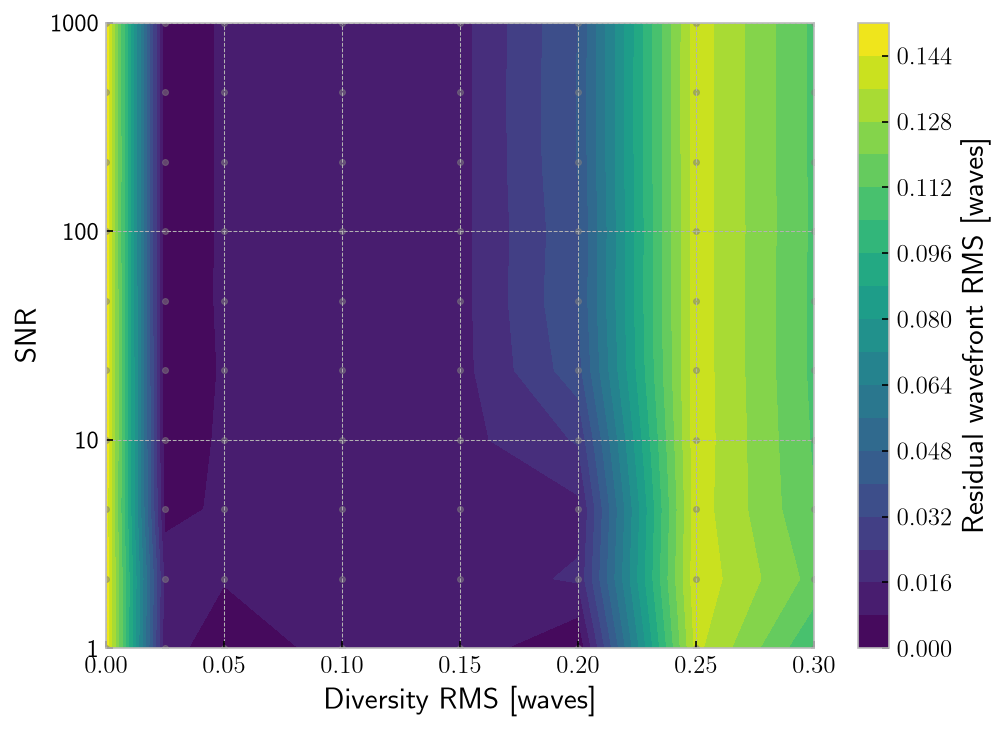

In [31]:
fig, ax = plt.subplots(dpi=150)
# Interpolate contours in log-SNR coordinates; ticks show the SNR itself.
log_snr = np.log10(snr_grid)
contours = ax.contourf(
    diversity_rms_grid, log_snr, residual_rms_grid,
    levels=20, cmap="viridis",
)
sampled_x, sampled_y = np.meshgrid(diversity_rms_grid, log_snr)
ax.scatter(sampled_x.ravel(), sampled_y.ravel(), s=8, c="gray", alpha=0.5)

ax.set_xlabel("Diversity RMS [waves]")
ax.set_ylabel("SNR")
ax.set_yticks([0, 1, 2, 3], labels=["1", "10", "100", "1000"])
fig.colorbar(contours, ax=ax, label="Residual wavefront RMS [waves]")
plt.show()
